# Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p "/content/drive/MyDrive/research/m-smithii-lifestyle-pangenome"
result_dir = "/content/drive/MyDrive/research/m-smithii-lifestyle-pangenome"

In [ ]:
!pip install -q condacolab

In [ ]:
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:19
🔁 Restarting kernel...


In [ ]:
!conda install -c conda-forge -c bioconda ppanggolin -y

Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: \ | / - done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - ppanggolin


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    aragorn-1.2.41             |       h7b50bb2_5         144 KB  bioconda
    aria2-1.37.0               |       hbc8128a_2         1.6 MB  conda-forge
    blosc-1.21.6               |       he440d0b_1          47 KB  conda-forge
    bokeh-3.9.0                |     pyhd8ed1ab_0         4.0 MB  conda-forge
    c-blosc2-2.16.0            |       h3122c55_0         335 KB  conda-forge
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    contourpy-1.3.3            |  py

In [ ]:
import pandas as pd
import glob
import os
import numpy as np
import scipy.stats as stats

In [ ]:
%cd $result_dir
%ls

/content/drive/MyDrive/research/m-smithii-lifestyle-pangenome
FINAL_annotated_lifestyle_genes.csv           lifestyle_specific_genes.csv
FINAL_annotated_lifestyle_genes_filtered.csv  m_smithii_alignment/
genomes/                                      m_smithii_map.txt
genomes-all_metadata.tsv                      m_smithii_matrix/
hq_m_smithii.tsv                              m_smithii_pangenome_out/
industrialized_m_smithii.tsv                  non_industrialized_m_smithii.tsv
itol_color_strip.txt                          r_heatmap_data.csv
itol_heatmap.txt                              r_metadata.csv


In [ ]:
!ppanggolin --version

ppanggolin 2.3.0


# Extract Metadata

In [ ]:
!wget https://ftp.ebi.ac.uk/pub/databases/metagenomics/mgnify_genomes/human-gut/v2.0.2/genomes-all_metadata.tsv

--2026-04-12 08:40:37--  https://ftp.ebi.ac.uk/pub/databases/metagenomics/mgnify_genomes/human-gut/v2.0.2/genomes-all_metadata.tsv
Resolving ftp.ebi.ac.uk (ftp.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.ebi.ac.uk (ftp.ebi.ac.uk)|193.62.193.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 115140145 (110M) [text/tab-separated-values]
Saving to: ‘genomes-all_metadata.tsv’

genomes-all_metadat 100%[===================>] 109.81M  29.0MB/s    in 3.8s    

2026-04-12 08:40:41 (29.0 MB/s) - ‘genomes-all_metadata.tsv’ saved [115140145/115140145]



In [ ]:
metadata = pd.read_table('genomes-all_metadata.tsv')
# metadata.head()

In [ ]:
# Extract the header (NR==1) OR rows matching M. smithii with >90% completeness and <5% contamination
!awk -F '\t' 'NR==1 || ($15 ~ /Methanobrevibacter.*smithii/ && $7 >= 90 && $8 <= 5)' genomes-all_metadata.tsv > hq_m_smithii.tsv

In [ ]:
# Print the Country column (18), sort them, and count the occurrences
!awk -F '\t' 'NR>1 {print $18}' hq_m_smithii.tsv | sort | uniq -c | sort -nr

    106 United States
     91 Israel
     66 United Kingdom
     65 Sweden
     63 Spain
     61 Austria
     40 China
     33 France
     26 Fiji
     22 Denmark
     17 Peru
     11 Netherlands
      8 Kazakhstan
      8 Germany
      8 Australia
      4 Madagascar
      4 Canada
      3 Russia
      2 NA
      2 Italy
      1 not provided
      1 Iceland


In [ ]:
# 1. Create the Non-Industrialized list
!awk -F '\t' '$18 ~ /Fiji|Peru|Madagascar/ {print $0}' hq_m_smithii.tsv > non_industrialized_m_smithii.tsv

# 2. Create the Industrialized list
!awk -F '\t' '$18 ~ /United States|United Kingdom/ {print $0}' hq_m_smithii.tsv > industrialized_m_smithii.tsv

# 3. Verify your final counts
!wc -l non_industrialized_m_smithii.tsv industrialized_m_smithii.tsv

   47 non_industrialized_m_smithii.tsv
  172 industrialized_m_smithii.tsv
  219 total


# Download MAGs

In [ ]:
# Create folders
!mkdir -p genomes/industrialized genomes/non_industrialized

# Download Non-Industrialized MAGs
!awk -F '\t' '{print $20}' non_industrialized_m_smithii.tsv | xargs -n 1 wget -P genomes/non_industrialized

# Download Industrialized MAGs
!awk -F '\t' '{print $20}' industrialized_m_smithii.tsv | xargs -n 1 wget -P genomes/industrialized

# time taken: 6 min in colab

--2026-04-12 08:59:47--  ftp://ftp.ebi.ac.uk/pub/databases/metagenomics/mgnify_genomes/human-gut/v2.0/all_genomes/MGYG0000021/MGYG000002163/genomes1/MGYG000008418.gff.gz
           => ‘genomes/non_industrialized/MGYG000008418.gff.gz’
Resolving ftp.ebi.ac.uk (ftp.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.ebi.ac.uk (ftp.ebi.ac.uk)|193.62.193.165|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /pub/databases/metagenomics/mgnify_genomes/human-gut/v2.0/all_genomes/MGYG0000021/MGYG000002163/genomes1 ... done.
==> SIZE MGYG000008418.gff.gz ... 586154
==> PASV ... done.    ==> RETR MGYG000008418.gff.gz ... done.
Length: 586154 (572K) (unauthoritative)

MGYG000008418.gff.g 100%[===================>] 572.42K  1.09MB/s    in 0.5s    

2026-04-12 08:59:49 (1.09 MB/s) - ‘genomes/non_industrialized/MGYG000008418.gff.gz’ saved [586154]

--2026-04-12 08:59:49--  ftp://ftp.ebi.ac.uk/pub/databases/metagenomics/mgnify

In [ ]:
!gunzip genomes/industrialized/*.gz
!gunzip genomes/non_industrialized/*.gz

# Create Map

In [ ]:
# @title Create Map
# Update the search path to look for the newly unzipped .gff files
files = glob.glob("genomes/*/*.gff")

with open("m_smithii_map.txt", "w") as f:
    for filepath in files:
        # Extract just the ID (e.g., MGYG000002446) for the name
        filename = os.path.basename(filepath)
        genome_id = filename.split('.')[0]
        f.write(f"{genome_id}\t{filepath}\n")

print(f"Map created with {len(files)} annotated genomes!")

Map created with 219 annotated genomes!


# Generate Matrix

In [ ]:
# Using the --anno flag for GFF files
!ppanggolin workflow --anno m_smithii_map.txt --cpu 2 --output m_smithii_pangenome_out
# # time taken: 15 min in colab

2026-04-12 09:08:02 utils.py:l240 INFO	Command: /usr/local/bin/ppanggolin workflow --anno m_smithii_map.txt --cpu 2 --output m_smithii_pangenome_out
2026-04-12 09:08:02 utils.py:l243 INFO	PPanGGOLiN version: 2.3.0
2026-04-12 09:08:02 utils.py:l997 INFO	8 parameters have a non-default value.
2026-04-12 09:08:02 annotate.py:l1620 INFO	Reading m_smithii_map.txt the list of genome files ...
100% 219/219 [00:50<00:00,  4.37file/s]
2026-04-12 09:08:54 annotate.py:l1495 INFO	No genetic code information found in the annotation files. Using the default translation table: 11.
2026-04-12 09:08:54 annotate.py:l1674 INFO	gene identifiers used in the provided annotation files were unique, PPanGGOLiN will use them.
2026-04-12 09:08:54 writeSequences.py:l84 INFO	Writing all CDS sequences in /tmp/clustering_tmpdir__2026-04-12_09-08-54_PID11246ft78r5et/nucleotide_sequences.fna
374300gene [00:01, 249323.58gene/s]
2026-04-12 09:08:55 cluster.py:l479 INFO	Clustering all of the genes sequences...
2026-04-12

In [ ]:
!ppanggolin write_pangenome -p m_smithii_pangenome_out/pangenome.h5 --csv --output m_smithii_matrix

2026-04-12 09:26:39 utils.py:l240 INFO	Command: /usr/local/bin/ppanggolin write_pangenome -p m_smithii_pangenome_out/pangenome.h5 --csv --output m_smithii_matrix
2026-04-12 09:26:39 utils.py:l243 INFO	PPanGGOLiN version: 2.3.0
2026-04-12 09:26:39 utils.py:l997 INFO	2 parameters have a non-default value.
2026-04-12 09:26:39 readBinaries.py:l123 INFO	Getting the current pangenome status
2026-04-12 09:26:39 readBinaries.py:l1513 INFO	Reading pangenome annotations...
100% 219/219 [00:00<00:00, 1677.16genome/s]
100% 18711/18711 [00:00<00:00, 63055.85contig/s]
100% 374300/374300 [00:06<00:00, 57131.28gene/s]
100% 7041/7041 [00:00<00:00, 64509.57gene/s]
2026-04-12 09:26:54 readBinaries.py:l1534 INFO	Reading pangenome gene families...
100% 374300/374300 [00:04<00:00, 80836.13gene family/s]
100% 10391/10391 [00:00<00:00, 43301.29gene family/s]
2026-04-12 09:26:59 writeFlatPangenome.py:l461 INFO	Writing the .csv file ...
2026-04-12 09:27:04 writeFlatPangenome.py:l545 INFO	Done writing the matrix

# Stats

In [ ]:
print("Loading the PPanGGOLiN matrix...")
df = pd.read_csv("m_smithii_matrix/matrix.csv", low_memory=False)

# PPanGGOLiN's Roary-style matrix uses 'Gene' as the first column
df.set_index('Gene', inplace=True)

ind_genomes = [os.path.basename(f).split('.')[0] for f in glob.glob("genomes/industrialized/*.gff")]
non_ind_genomes = [os.path.basename(f).split('.')[0] for f in glob.glob("genomes/non_industrialized/*.gff")]

# Ensure columns match what successfully made it into the matrix
ind_cols = [c for c in ind_genomes if c in df.columns]
non_ind_cols = [c for c in non_ind_genomes if c in df.columns]

print(f"Comparing {len(ind_cols)} Industrialized vs {len(non_ind_cols)} Non-Industrialized genomes.")

results = []
total_genomes = len(ind_cols) + len(non_ind_cols)

# Scan every gene family
for index, row in df.iterrows():

    # Count presences (In this CSV format, presence is text, absence is NaN/empty)
    ind_present = row[ind_cols].notna().sum()
    ind_absent = len(ind_cols) - ind_present

    non_ind_present = row[non_ind_cols].notna().sum()
    non_ind_absent = len(non_ind_cols) - non_ind_present

    total_present = ind_present + non_ind_present

    # The Fix: Mathematically isolate the "Accessory" genome
    # Skip the Core genome (genes present in >95% of ALL genomes) and empty rows
    if 0 < total_present < (0.95 * total_genomes):

        # Run Fisher's Exact Test
        oddsratio, pvalue = stats.fisher_exact([[ind_present, ind_absent], [non_ind_present, non_ind_absent]])

        # Calculate prevalence percentages
        ind_prev = (ind_present / len(ind_cols)) * 100
        non_ind_prev = (non_ind_present / len(non_ind_cols)) * 100

        # Filter for significant lifestyle differences (p < 0.05 and >30% difference in prevalence)
        diff = abs(ind_prev - non_ind_prev)

        if diff >= 30 and pvalue < 0.05:
            results.append({
                'Gene_Family': index,
                'Ind_Prevalence_%': round(ind_prev, 2),
                'Non_Ind_Prevalence_%': round(non_ind_prev, 2),
                'p_value': pvalue
            })

# Safety check to prevent the KeyError if no genes meet the strict threshold
if len(results) > 0:
    sig_df = pd.DataFrame(results).sort_values(by='p_value')
    sig_df.to_csv("lifestyle_specific_genes.csv", index=False)
    print(f"\nSuccess! Found {len(sig_df)} significantly different accessory gene families.")
    # display(sig_df.head(15))
else:
    print("\nNo genes met the strict 30% difference threshold. Try lowering the 'diff >= 30' threshold in the script!")

Loading the PPanGGOLiN matrix...
Comparing 172 Industrialized vs 47 Non-Industrialized genomes.

Success! Found 64 significantly different accessory gene families.


# What do these genes actually do?

In [ ]:
# @title Annotation
# Load your successful results
sig_df = pd.read_csv("lifestyle_specific_genes.csv")

print("Scanning downloaded GFF files for functional annotations...")

def get_annotation(gene_id):
    # Extract the original Genome ID from the Gene Family ID (e.g., MGYG000081171)
    parts = gene_id.split('_')
    if len(parts) >= 2:
        genome_id = parts[0]

        # Locate the specific GFF file in your folders
        gff_files = glob.glob(f"genomes/*/{genome_id}.gff")

        if gff_files:
            gff_file = gff_files[0]
            with open(gff_file, 'r') as f:
                for line in f:
                    if line.startswith('#'): continue
                    cols = line.strip().split('\t')

                    # Ensure it's a valid GFF line
                    if len(cols) == 9:
                        attributes = cols[8]

                        # Find the exact gene in the GFF
                        if f"ID={gene_id}" in attributes or f"Name={gene_id}" in attributes or gene_id in attributes:

                            # Extract the 'product' description from the attributes column
                            for attr in attributes.split(';'):
                                if attr.startswith('product='):
                                    # Clean up the text by removing %20 URL encoding and commas
                                    func = attr.replace('product=', '').replace('%20', ' ').replace('%2C', ',')
                                    return func

                            # If no product is listed, check for an inference/Pfam domain
                            return "Hypothetical / Uncharacterized Protein"
    return "Annotation not found"

# Apply the function to your 64 genes
sig_df['Biological_Function'] = sig_df['Gene_Family'].apply(get_annotation)

# Rearrange columns to make it readable
cols = ['Gene_Family', 'Biological_Function', 'Ind_Prevalence_%', 'Non_Ind_Prevalence_%', 'p_value']
sig_df = sig_df[cols]

# Save the final annotated file
sig_df.to_csv("FINAL_annotated_lifestyle_genes.csv", index=False)

print("\nAnnotation Complete!")
# display(sig_df.head(20))

Scanning downloaded GFF files for functional annotations...

Annotation Complete!


In [ ]:
# @title Filter
import pandas as pd

# Read the final annotated file
final_annotated_df = pd.read_csv("FINAL_annotated_lifestyle_genes.csv")

# Filter out 'hypothetical protein' from the 'Biological_Function' column
filtered_df = final_annotated_df[final_annotated_df['Biological_Function'] != 'hypothetical protein']

print(f"Displaying {len(filtered_df)} significantly different accessory gene families after filtering out hypothetical proteins")
filtered_df.to_csv("FINAL_annotated_lifestyle_genes_filtered.csv", index=False)
print("Filtered lifestyle-specific genes saved to FINAL_annotated_lifestyle_genes_filtered.csv")

display(filtered_df)

Displaying 9 significantly different accessory gene families after filtering out hypothetical proteins
Filtered lifestyle-specific genes saved to FINAL_annotated_lifestyle_genes_filtered.csv


,Gene_Family,Biological_Function,Ind_Prevalence_%,Non_Ind_Prevalence_%,p_value
2,MGYG000211034_00116,"2,3,4,5-tetrahydropyridine-2,6-dicarboxylate N...",0.00,36.17,3.007438e-13
8,MGYG000259779_00903,Sensor histidine kinase RcsC,22.67,70.21,3.156866e-09
21,MGYG000211034_01500,Cobalamin import system permease protein BtuC,50.00,91.49,7.881127e-08
30,MGYG000259779_01487,Vitamin B12 import ATP-binding protein BtuD,8.72,42.55,3.423178e-07
31,MGYG000155887_00579,Vitamin B12-binding protein,50.00,89.36,5.904120e-07
34,MGYG000259779_01153,ATP synthase subunit c,93.02,61.70,6.326909e-07
39,MGYG000171336_01359,Polyferredoxin protein MvhB,81.40,44.68,1.632173e-06
47,MGYG000190668_00503,Beta-barrel assembly-enhancing protease,12.21,42.55,1.148652e-05
49,MGYG000277122_01361,Vitamin B12 import ATP-binding protein BtuD,70.35,34.04,1.316632e-05


# Build the Core Genome Phylogenetic Tree

In [ ]:
!ppanggolin msa -p m_smithii_pangenome_out/pangenome.h5 --partition persistent --phylo --output m_smithii_alignment
# time taken: 25 min in colab

2026-04-12 09:35:06 utils.py:l240 INFO	Command: /usr/local/bin/ppanggolin msa -p m_smithii_pangenome_out/pangenome.h5 --partition persistent --phylo --output m_smithii_alignment
2026-04-12 09:35:06 utils.py:l243 INFO	PPanGGOLiN version: 2.3.0
2026-04-12 09:35:06 utils.py:l997 INFO	3 parameters have a non-default value.
2026-04-12 09:35:06 readBinaries.py:l123 INFO	Getting the current pangenome status
2026-04-12 09:35:06 readBinaries.py:l1513 INFO	Reading pangenome annotations...
100% 219/219 [00:00<00:00, 5713.17genome/s]
100% 18711/18711 [00:00<00:00, 67505.40contig/s]
100% 374300/374300 [00:09<00:00, 39908.57gene/s]
100% 7041/7041 [00:00<00:00, 69665.79gene/s]
2026-04-12 09:35:22 readBinaries.py:l1522 INFO	Reading pangenome gene dna sequences...
100% 374300/374300 [00:02<00:00, 169599.47gene/s]
2026-04-12 09:35:28 readBinaries.py:l1534 INFO	Reading pangenome gene families...
100% 374300/374300 [00:05<00:00, 70497.56gene family/s]
100% 10391/10391 [00:00<00:00, 55801.26gene family/s]


In [ ]:
# @title Generate iTOL annotation files

print("Generating iTOL annotation files...")

# Load your freshly filtered genes and the original full matrix
genes_df = pd.read_csv("FINAL_annotated_lifestyle_genes_filtered.csv")
matrix_df = pd.read_csv("m_smithii_matrix/matrix.csv", low_memory=False)
matrix_df.set_index('Gene', inplace=True)

target_genes = genes_df['Gene_Family'].tolist()
labels = genes_df['Biological_Function'].tolist()

# Clean up labels so iTOL doesn't get confused by internal commas
clean_labels = [str(label).replace(',', '') for label in labels]

# Extract only our significant genes from the big matrix
subset_matrix = matrix_df.loc[target_genes].copy()

# Identify our genomes based on the Colab folders
ind_genomes = [os.path.basename(x).split('.')[0] for x in glob.glob("genomes/industrialized/*.gff")]
non_ind_genomes = [os.path.basename(x).split('.')[0] for x in glob.glob("genomes/non_industrialized/*.gff")]
all_genomes = ind_genomes + non_ind_genomes

# Keep only the genome columns
subset_matrix = subset_matrix[[col for col in all_genomes if col in subset_matrix.columns]]

# Convert presence to 1 and absence (NaN) to 0
subset_matrix = subset_matrix.notna().astype(int)
heatmap_data = subset_matrix.T # Transpose so genomes are rows

# 1. WRITE THE HEATMAP FILE
with open("itol_heatmap.txt", "w") as f:
    f.write("DATASET_HEATMAP\nSEPARATOR COMMA\nDATASET_LABEL,Metabolic Structural Variations\n")
    f.write("COLOR,#336699\n")
    f.write("FIELD_LABELS," + ",".join(clean_labels) + "\n")
    f.write("COLOR_MIN,#ffffff\n") # White for absent
    f.write("COLOR_MAX,#2c3e50\n") # Dark blue for present

    # --- The Magic Lines: Overriding the Gradient Legend ---
    f.write("LEGEND_TITLE,Gene Presence\n")
    f.write("LEGEND_SHAPES,1,1\n") # '1' tells iTOL to use square boxes
    f.write("LEGEND_COLORS,#ffffff,#2c3e50\n")
    f.write("LEGEND_LABELS,Absent,Present\n")
    # ------------------------------------------------------

    f.write("DATA\n")
    for genome in heatmap_data.index:
        values = heatmap_data.loc[genome].astype(str).tolist()
        f.write(f"{genome}," + ",".join(values) + "\n")

# 2. WRITE THE LIFESTYLE COLOR STRIP
with open("itol_color_strip.txt", "w") as f:
    f.write("DATASET_COLORSTRIP\nSEPARATOR COMMA\nDATASET_LABEL,Industrialization\n")
    f.write("STRIP_WIDTH,25\nCOLOR_BRANCHES,1\nDATA\n")
    for genome in heatmap_data.index:
        if genome in ind_genomes:
            f.write(f"{genome},#e74c3c,Industrialized\n") # Red
        elif genome in non_ind_genomes:
            f.write(f"{genome},#3498db,Non-Industrialized\n") # Blue

print("Done! Files saved: 'itol_heatmap.txt' and 'itol_color_strip.txt'")

Generating iTOL annotation files...
Done! Files saved: 'itol_heatmap.txt' and 'itol_color_strip.txt'


In [ ]:
# https://usegalaxy.org/jobs/bbd44e69cb8906b58ba85cfb8304b8ef/view

# Graph

In [ ]:
!ls
!ls m_smithii_alignment
!ls m_smithii_matrix
!ls m_smithii_pangenome_out
!ls m_smithii_pangenome_out/partitions

FINAL_annotated_lifestyle_genes.csv	      lifestyle_specific_genes.csv
FINAL_annotated_lifestyle_genes_filtered.csv  m_smithii_alignment
genomes					      m_smithii_map.txt
genomes-all_metadata.tsv		      m_smithii_matrix
hq_m_smithii.tsv			      m_smithii_pangenome_out
industrialized_m_smithii.tsv		      non_industrialized_m_smithii.tsv
itol_color_strip.txt			      r_heatmap_data.csv
itol_heatmap.txt			      r_metadata.csv
msa_persistent_protein	persistent_genome_alignment.aln
matrix.csv
gene_families.tsv	    mean_persistent_duplication.tsv  partitions
gene_presence_absence.Rtab  pangenomeGraph.gexf		     proksee
genomes_statistics.tsv	    pangenomeGraph.json		     table
gff			    pangenomeGraph_light.gexf	     tile_plot.html
matrix.csv		    pangenome.h5		     Ushaped_plot.html
cloud.txt	     exact_core.txt  S1.txt  S3.txt	soft_accessory.txt
exact_accessory.txt  persistent.txt  S2.txt  shell.txt	soft_core.txt


Extracting exact gene counts from PPanGGOLiN output...
Found: 1400 Persistent, 944 Shell, 8047 Cloud genes.
Perfection achieved! Figure 2 saved as 'Figure_2_Pangenome_Partition.pdf' and '.png'


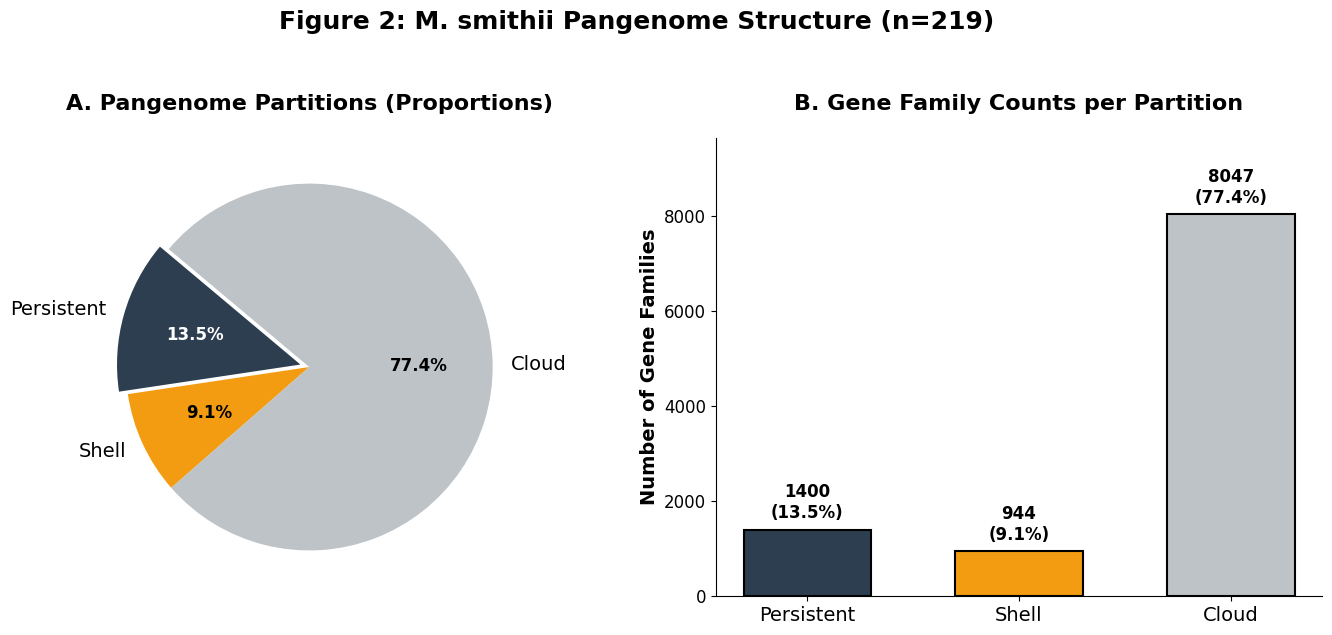

In [ ]:
# @title Partition Plot
import matplotlib.pyplot as plt
import numpy as np
import os

print("Extracting exact gene counts from PPanGGOLiN output...")

# ==============================================================================
# 1. AUTOMATICALLY READ THE DATA
# ==============================================================================
# File paths based exactly on your directory structure
persistent_file = "m_smithii_pangenome_out/partitions/persistent.txt"
shell_file = "m_smithii_pangenome_out/partitions/shell.txt"
cloud_file = "m_smithii_pangenome_out/partitions/cloud.txt"

def count_genes(filepath):
    """Counts the number of non-empty lines (gene families) in a given text file."""
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            return sum(1 for line in f if line.strip())
    else:
        print(f"Error: Could not find {filepath}")
        return 0

# Extract the exact numbers automatically
persistent_genes = count_genes(persistent_file)
shell_genes = count_genes(shell_file)
cloud_genes = count_genes(cloud_file)

print(f"Found: {persistent_genes} Persistent, {shell_genes} Shell, {cloud_genes} Cloud genes.")

# ==============================================================================
# 2. SETUP THE DATA & AESTHETICS
# ==============================================================================
categories = ['Persistent', 'Shell', 'Cloud']
counts = [persistent_genes, shell_genes, cloud_genes]
total_genes = sum(counts)
percentages = [(count / total_genes) * 100 for count in counts]

# Professional, colorblind-friendly palette
colors = ['#2c3e50', '#f39c12', '#bdc3c7'] # Dark Blue, Orange, Light Grey

# Set up a side-by-side figure (1 Pie Chart, 1 Bar Plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ==============================================================================
# 3. GENERATE PIE CHART (Left Panel)
# ==============================================================================
explode = (0.05, 0, 0)

wedges, texts, autotexts = ax1.pie(
    counts,
    explode=explode,
    labels=categories,
    colors=colors,
    autopct='%1.1f%%',
    shadow=False,
    startangle=140,
    textprops=dict(color="black", fontsize=14)
)

plt.setp(autotexts, size=12, weight="bold")
autotexts[0].set_color('white')
ax1.set_title("A. Pangenome Partitions (Proportions)", fontsize=16, weight='bold', pad=20)

# ==============================================================================
# 4. GENERATE BAR PLOT (Right Panel)
# ==============================================================================
bars = ax2.bar(categories, counts, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Add exact numbers and percentages on top of the bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + (max(counts) * 0.02),
        f'{int(height)}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=12,
        weight='bold'
    )

ax2.set_title("B. Gene Family Counts per Partition", fontsize=16, weight='bold', pad=20)
ax2.set_ylabel("Number of Gene Families", fontsize=14, weight='bold')
ax2.set_ylim(0, max(counts) * 1.2)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==============================================================================
# 5. FINALIZE AND EXPORT
# ==============================================================================
plt.suptitle("Figure 2: M. smithii Pangenome Structure (n=219)", fontsize=18, weight='bold', y=1.05)
plt.tight_layout()

# Save as a publication-ready PDF and a PNG for quick viewing
plt.savefig("Figure_2_Pangenome_Partition.pdf", dpi=300, bbox_inches='tight')
plt.savefig("Figure_2_Pangenome_Partition.png", dpi=300, bbox_inches='tight')

print("Perfection achieved! Figure 2 saved as 'Figure_2_Pangenome_Partition.pdf' and '.png'")
plt.show()

1. Loading pangenome matrix...
2. Identifying host lifestyle cohorts...
3. Calculating Jaccard distances and computing PCoA...
4. Generating publication-ready vector graphic...
Perfection achieved! Saved as 'Supp_Fig_1_PCoA.pdf' and '.png'


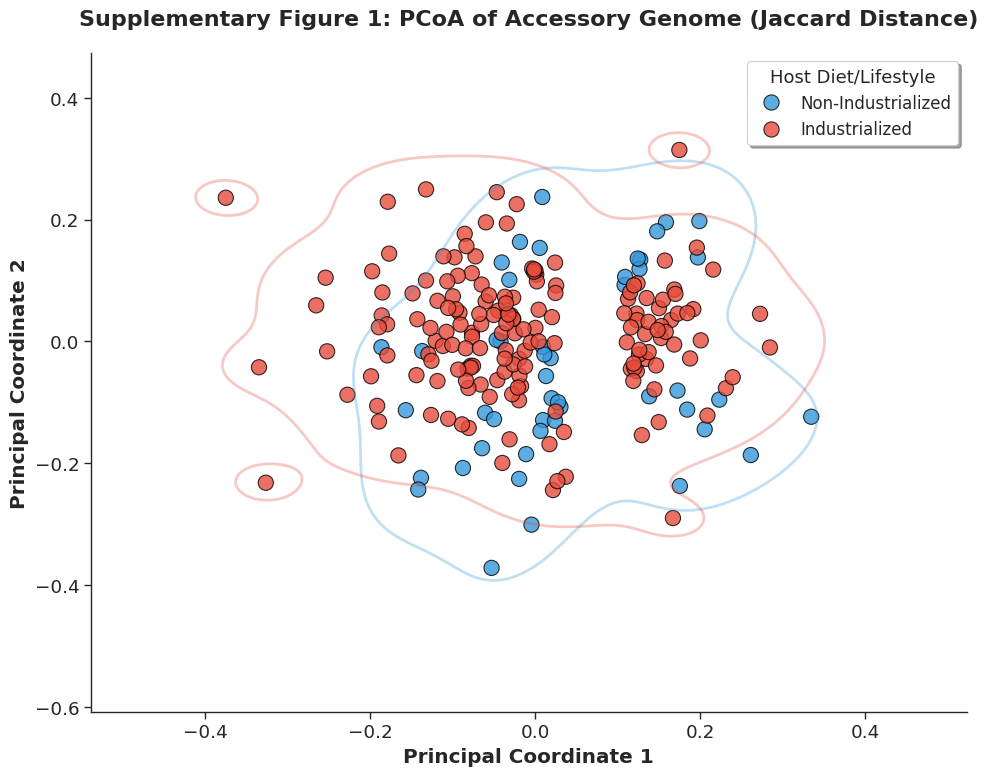

In [ ]:
# @title PCoA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
import glob
import os

print("1. Loading pangenome matrix...")
# Load the full matrix and convert to binary presence (1) / absence (0)
matrix_df = pd.read_csv("m_smithii_matrix/matrix.csv", low_memory=False)
matrix_df.set_index('Gene', inplace=True)
pa_matrix = matrix_df.notna().astype(int).T # Transpose so genomes are rows

print("2. Identifying host lifestyle cohorts...")
# Identify our genomes based on the Colab folders
ind_genomes = [os.path.basename(x).split('.')[0] for x in glob.glob("genomes/industrialized/*.gff")]
non_ind_genomes = [os.path.basename(x).split('.')[0] for x in glob.glob("genomes/non_industrialized/*.gff")]

# Filter matrix to only include these genomes (safety check)
valid_genomes = [g for g in pa_matrix.index if g in ind_genomes or g in non_ind_genomes]
pa_matrix = pa_matrix.loc[valid_genomes]

# Create a list of labels for coloring the plot
lifestyles = ['Industrialized' if g in ind_genomes else 'Non-Industrialized' for g in valid_genomes]

print("3. Calculating Jaccard distances and computing PCoA...")
# Calculate Jaccard distance (perfect for binary accessory genome data)
dist_matrix = pdist(pa_matrix, metric='jaccard')
dist_square = squareform(dist_matrix)

# Perform PCoA (using MDS with a precomputed distance matrix)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
pcoa_results = mds.fit_transform(dist_square)

# Create a clean DataFrame for plotting
plot_df = pd.DataFrame({
    'PCoA1': pcoa_results[:, 0],
    'PCoA2': pcoa_results[:, 1],
    'Lifestyle': lifestyles
})

print("4. Generating publication-ready vector graphic...")
# ==============================================================================
# PLOTTING ESTHETICS
# ==============================================================================
plt.figure(figsize=(10, 8))
sns.set_theme(style="ticks", context="paper", font_scale=1.5)

# Professional color palette mapping
palette = {"Industrialized": "#e74c3c", "Non-Industrialized": "#3498db"}

# Draw the scatter plot
ax = sns.scatterplot(
    data=plot_df,
    x='PCoA1',
    y='PCoA2',
    hue='Lifestyle',
    palette=palette,
    s=120,          # Size of dots
    edgecolor='black',
    linewidth=0.8,
    alpha=0.8       # Slight transparency
)

# Add 95% confidence ellipses to prove statistical separation
sns.kdeplot(
    data=plot_df,
    x='PCoA1',
    y='PCoA2',
    hue='Lifestyle',
    palette=palette,
    levels=2,
    alpha=0.3,
    linewidths=2,
    warn_singular=False
)

# Clean up the axes and legend
plt.title("Supplementary Figure 1: PCoA of Accessory Genome (Jaccard Distance)", fontsize=16, weight='bold', pad=20)
plt.xlabel("Principal Coordinate 1", weight='bold')
plt.ylabel("Principal Coordinate 2", weight='bold')

# Despine for that clean, modern journal look
sns.despine()
plt.legend(title="Host Diet/Lifestyle", title_fontsize='13', fontsize='12', loc='best', frameon=True, shadow=True)

plt.tight_layout()

# Save perfectly as PDF and PNG
plt.savefig("Supp_Fig_1_PCoA.pdf", dpi=300, bbox_inches='tight')
plt.savefig("Supp_Fig_1_PCoA.png", dpi=300, bbox_inches='tight')

print("Perfection achieved! Saved as 'Supp_Fig_1_PCoA.pdf' and '.png'")
plt.show()

In [ ]:
# @title Supplementary Table 1: MAG Metadata and Quality Metrics
import pandas as pd
import glob
import os

print("1. Loading metadata...")
metadata_df = pd.read_csv("genomes-all_metadata.tsv", sep='\t')

# ==============================================================================
# 2. ISOLATE THE EXACT 219 GENOMES
# ==============================================================================
# Identify lifestyles based directly on the files sitting in your folders
ind_genomes = [os.path.basename(x).split('.')[0] for x in glob.glob("genomes/industrialized/*.gff")]
non_ind_genomes = [os.path.basename(x).split('.')[0] for x in glob.glob("genomes/non_industrialized/*.gff")]

# Combine them into our master list of actual analyzed genomes
all_final_genomes = ind_genomes + non_ind_genomes
print(f"Found {len(all_final_genomes)} final genomes actively used in the pangenome folders.")

# ==============================================================================
# 3. FILTER AND FORMAT THE TABLE
# ==============================================================================
print("2. Filtering metadata to match the manuscript...")

# Filter metadata to ONLY include the 219 genomes
final_table = metadata_df[metadata_df['Genome'].isin(all_final_genomes)].copy()

# Map the Lifestyle column
def determine_lifestyle(genome_id):
    if genome_id in ind_genomes:
        return 'Industrialized'
    elif genome_id in non_ind_genomes:
        return 'Non-Industrialized'
    else:
        return 'Unknown'

final_table['Host_Lifestyle'] = final_table['Genome'].apply(determine_lifestyle)

# Select and reorder only the columns a reviewer actually wants to see
cols_to_keep = [
    'Genome', 'Host_Lifestyle', 'Country', 'Continent',
    'Completeness', 'Contamination', 'Length', 'N_contigs', 'N50', 'GC_content'
]
# Ensure we only try to keep columns that actually exist in your file
final_cols = [c for c in cols_to_keep if c in final_table.columns]
final_table = final_table[final_cols]

# ==============================================================================
# 4. EXPORT
# ==============================================================================
output_filename = "Supplementary_Table_1_MAG_Metrics.csv"
final_table.to_csv(output_filename, index=False)

print(f"\nPerfection achieved! Table saved as '{output_filename}'")
print(f"Total genomes in your Supplementary Table: {len(final_table)}")
print("\nPreview of your clean Supplementary Table:")
display(final_table.head())

1. Loading metadata...
Found 219 final genomes actively used in the pangenome folders.
2. Filtering metadata to match the manuscript...

Perfection achieved! Table saved as 'Supplementary_Table_1_MAG_Metrics.csv'
Total genomes in your Supplementary Table: 219

Preview of your clean Supplementary Table:


,Genome,Host_Lifestyle,Country,Continent,Completeness,Contamination,Length,N_contigs,N50,GC_content
2432,MGYG000002446,Industrialized,United States,North America,100.00,0.00,1926345,16,240345,30.29
8256,MGYG000008418,Non-Industrialized,Fiji,Oceania,100.00,0.13,1744052,23,164533,31.09
10198,MGYG000010360,Industrialized,United States,North America,93.26,1.66,1596396,218,9710,31.33
11396,MGYG000011558,Industrialized,United Kingdom,Europe,98.13,1.60,1703652,201,14924,31.33
11928,MGYG000012090,Industrialized,United States,North America,99.73,0.00,1791997,66,73601,31.25


1. Loading MAG metrics data...
2. Generating publication-ready scatter plot...

Perfection achieved! Saved as 'Supp_Fig_2_MAG_Quality.pdf' and '.png'


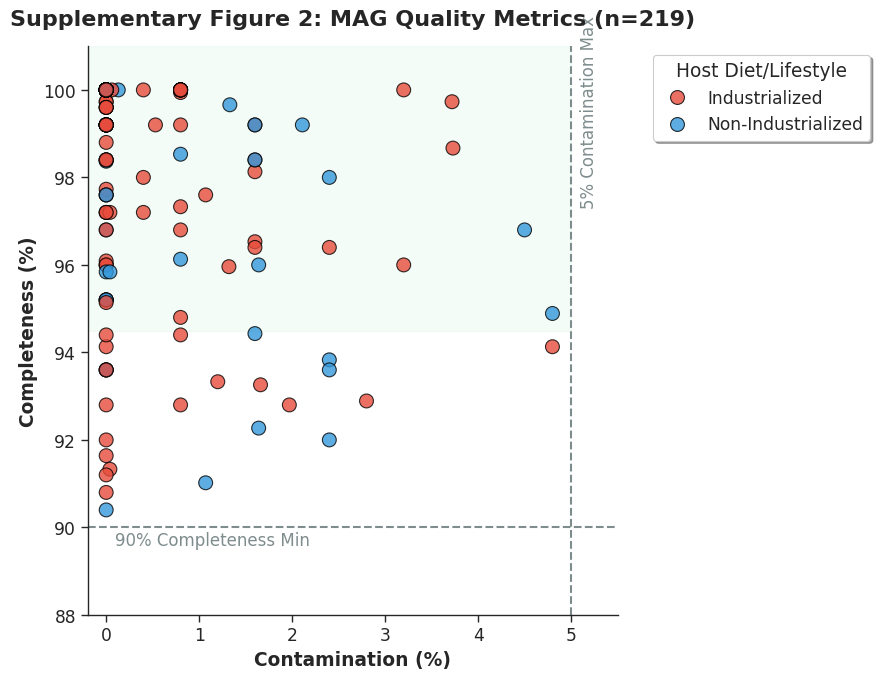

In [ ]:
# @title Scatter Plot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Loading MAG metrics data...")
# Load the perfectly filtered table we just generated
df = pd.read_csv("Supplementary_Table_1_MAG_Metrics.csv")

print("2. Generating publication-ready scatter plot...")
# Set up the figure aesthetics
plt.figure(figsize=(9, 7))
sns.set_theme(style="ticks", context="paper", font_scale=1.4)

# Professional color palette mapping matching your previous figures
palette = {"Industrialized": "#e74c3c", "Non-Industrialized": "#3498db"}

# Draw the scatter plot
ax = sns.scatterplot(
    data=df,
    x='Contamination',
    y='Completeness',
    hue='Host_Lifestyle',
    palette=palette,
    s=100,          # Size of dots
    edgecolor='black',
    linewidth=0.8,
    alpha=0.8       # Slight transparency so overlapping genomes are visible
)

# Add dashed threshold lines to explicitly show your quality cutoff criteria
plt.axvline(x=5, color='#7f8c8d', linestyle='--', linewidth=1.5, zorder=0)
plt.axhline(y=90, color='#7f8c8d', linestyle='--', linewidth=1.5, zorder=0)

# Add text labels for the threshold lines
plt.text(5.1, 99.5, '5% Contamination Max', color='#7f8c8d', fontsize=12, va='center', rotation=90)
plt.text(0.1, 89.6, '90% Completeness Min', color='#7f8c8d', fontsize=12, ha='left')

# Highlight the "High-Quality Zone" background (top-left quadrant)
plt.axvspan(-1, 5, ymin=0.5, ymax=1.0, color='#2ecc71', alpha=0.05, zorder=-1) # Very faint green shading

# Clean up the axes and add titles
plt.title("Supplementary Figure 2: MAG Quality Metrics (n=219)", fontsize=16, weight='bold', pad=15)
plt.xlabel("Contamination (%)", weight='bold')
plt.ylabel("Completeness (%)", weight='bold')

# Dynamically set axis limits to ensure the threshold lines are visible
plt.xlim(-0.2, max(5.5, df['Contamination'].max() + 0.5))
plt.ylim(min(88, df['Completeness'].min() - 2), 101)

# Remove top and right borders for a modern journal look
sns.despine()

# Adjust the legend
plt.legend(title="Host Diet/Lifestyle", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True)

plt.tight_layout()

# Save perfectly as PDF and PNG
plt.savefig("Supp_Fig_2_MAG_Quality.pdf", dpi=300, bbox_inches='tight')
plt.savefig("Supp_Fig_2_MAG_Quality.png", dpi=300, bbox_inches='tight')

print("\nPerfection achieved! Saved as 'Supp_Fig_2_MAG_Quality.pdf' and '.png'")
plt.show()